In [14]:
# neccessary imports
import warnings
warnings.filterwarnings(action='ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [15]:
# randomly generated data
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, 
                          n_redundant=0, n_classes=2, n_clusters_per_class=1,
                          random_state=41, hypercube=False, class_sep=20)

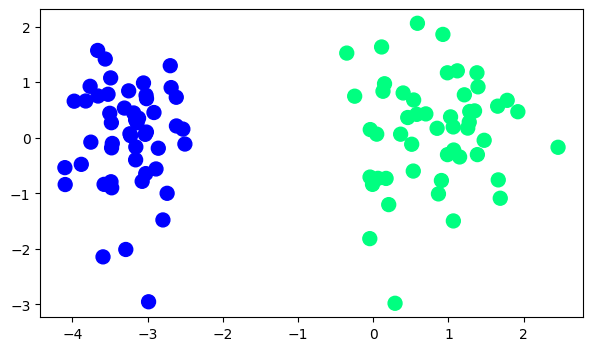

In [16]:
# plotting the data
plt.figure(figsize=(7,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(penalty=None, solver='sag')
LR.fit(X,y)

LogisticRegression(penalty=None, solver='sag')

In [18]:
print(LR.coef_)
print(LR.intercept_)

[[4.89268282 0.23651266]]
[5.85165119]


In [19]:
m1 = -(LR.coef_[0][0] / LR.coef_[0][1])
b1 = -(LR.intercept_ / LR.coef_[0][1])

In [20]:
x_input = np.linspace(-3, 3, 100)
y_input = m1 * x_input + b1

In [21]:
def GD(X,y):
    """
    Performs gradient descent optimization to find the optimal weights for logistic regression

    Parameters:
    X (np.ndarray): Feature matrix of shape (m, n), where m is the no. of samples and n is the no. of features
    y (np.ndarray): Target vector of shape (m,) containing binary labels (0 or 1).

    Returns:
    tuple:
        - weights (np.ndarray): Optimized weight vector (excluding the bias term)
        - bias (float): Optimized bias term
    """
    # Add bias term (column of ones) to feature matrix X
    X = np.insert(X, 0, 1, axis=1) # Shape becomes (m, n+1)

    # Initalize weights with ones (including bias weight)
    weights = np.ones(X.shape[1]) # Shape (n+1,)

    # Learning rate
    lr = 0.5

    # Perform gradient descent for 2500 iterations
    for i in range(2500):
        
        # Compute predicted probabilities using the Sigmoid function
        y_hat = sigmoid(np.dot(X, weights)) # y^hat-matrix
        
        # Compute gradient and update weights
        weights = weights + lr * (np.dot((y - y_hat),X) / X.shape[0]) # update rule

    # Return optimized weights (excluding bias term) and bias seperately
    return weights[1:], weights[0]

In [22]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [23]:
coef_, intercept_ = GD(X,y)

In [24]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [25]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m * x_input1 + b

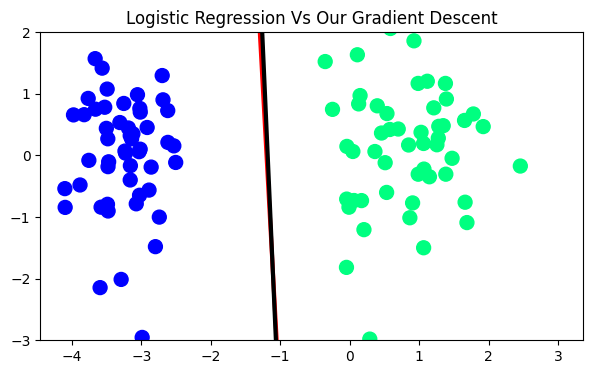

In [26]:
plt.figure(figsize=(7,4))
plt.title("Logistic Regression Vs Our Gradient Descent")
plt.plot(x_input, y_input, color='red', linewidth=3) # Logistic Regression' Line
plt.plot(x_input1, y_input1, color='black', linewidth=3) # GD functions' Line
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)
plt.show()

#### - By increasing the no. epochs our model is improving.